In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("All libraries are imported successfully")

All libraries are imported successfully


In [5]:
df=pd.read_csv('Data_file - data_file.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [6]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [8]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df['ocean_proximity'].head(5)

0    NEAR BAY
1    NEAR BAY
2    NEAR BAY
3    NEAR BAY
4    NEAR BAY
Name: ocean_proximity, dtype: object

In [10]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

#if we observe the above output there are total 207 null values in total_bedrooms.
inorder to remove null values i can use mean() or median 

We need to see whether total_bedrooms has:

Normal distribution?
Extreme outliers?
Strong skewness?

Because:

Mean is affected by extreme values.
Median is much less affected by extreme values.


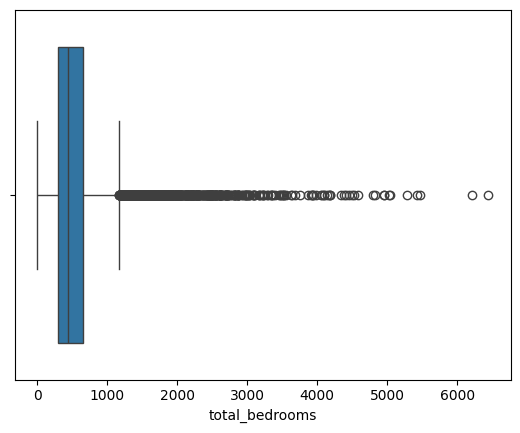

In [11]:
sns.boxplot(x=df['total_bedrooms'])
plt.show()

What do you see?
Are there dots outside the whiskers?
✅ Yes, a lot of them.
Are the outliers mostly on the left or right?
✅ Right side.
What does that tell us?
Some houses have extremely high numbers of bedrooms compared to most houses.
The distribution is right-skewed.


Mean gets pulled toward extreme values (outliers).
Median is much more stable.

In [12]:
df=df.fillna(df['total_bedrooms'].median())

In [13]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [21]:
#encoding

In [14]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Since there is no natural order, Label Encoding is risky.

For example:

INLAND = 0
NEAR BAY = 1
ISLAND = 2

The model may think:

ISLAND > NEAR BAY > INLAND

which is meaningless.


So what should we use?

Think about this representation:

INLAND	NEAR BAY	ISLAND
1	0	0
0	1	0
0	0	1

we use one hot encoding here. we are having 5 unique columns and its enough to operate with 4 ? think why? and yes you know the answer!!😊

In [15]:
ocean_dummy=pd.get_dummies(df['ocean_proximity'],drop_first=True)
df=pd.concat([df,ocean_dummy],axis=1)
df.head(5)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,False,False,True,False


In [18]:
print(type(ocean_dummy))
df=df.loc[:,~df.columns.duplicated()]
df.head(5)

<class 'pandas.core.frame.DataFrame'>


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,False,False,True,False


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
 10  INLAND              20640 non-null  bool   
 11  ISLAND              20640 non-null  bool   
 12  NEAR BAY            20640 non-null  bool   
 13  NEAR OCEAN          20640 non-null  bool   
dtypes: bool(4), float64(4), int64(5), object(1)
memory usage: 1.7+ MB


In [31]:
##EDA FOR FEATURE RELATIONSHIPS


In [20]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'INLAND', 'ISLAND', 'NEAR BAY',
       'NEAR OCEAN'],
      dtype='object')

In [21]:
df.drop('ocean_proximity',axis=1,inplace=True)


In [73]:
df=df.loc[:,~df.columns.duplicated()]

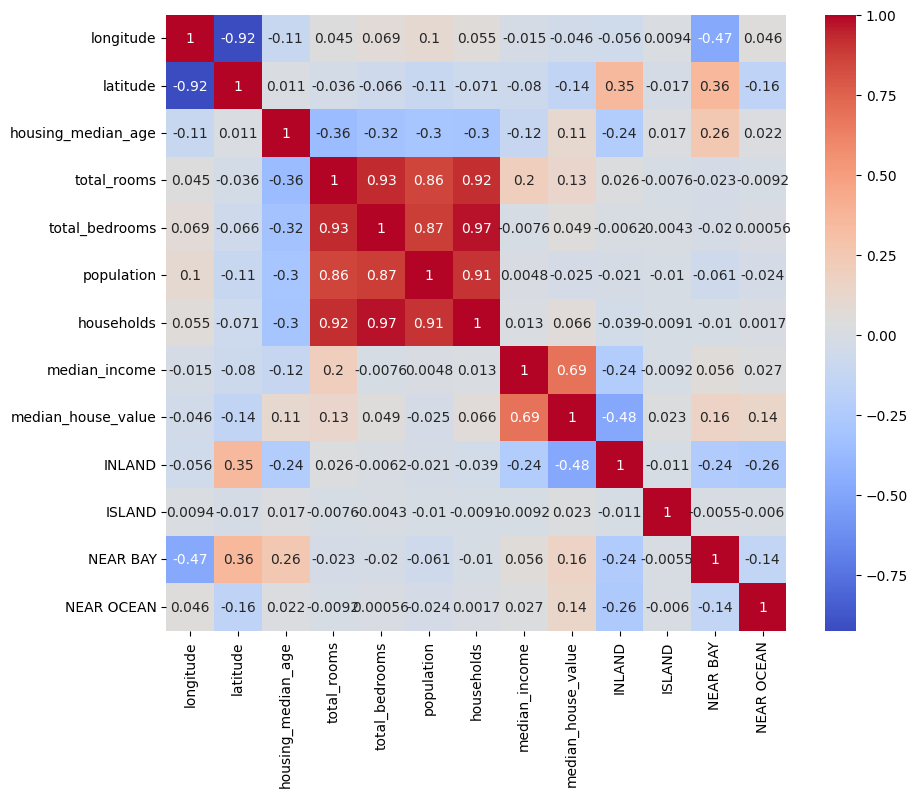

In [74]:
df.drop_duplicates(inplace=True)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

Feature Selection

In [24]:
X=df[['median_income']]
y=df['median_house_value']

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

Train the Model

In [26]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


median_house_value = m × median_income + c

Predictions

In [78]:
y_pred=model.predict(X_test)

In [79]:
from sklearn.metrics import mean_squared_error
import numpy as np
rsme=np.sqrt(mean_squared_error(y_test,y_pred))
print(rsme)

84209.01241414454


In [80]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype='object')

In [81]:
df['median_house_value'].mean()

np.float64(206855.81690891474)

In [82]:
print((84209.01241414454/206855.81690891474)*100)

40.70903766328431


so the error is nearly 41%

What does this mean?

Your Simple Linear Regression model using only:

median_income

is making an average error of about 41% of the average house value.

Now think like a data scientist

Is predicting house price using only:median_income enough?

Or are there other factors?


So what do you expect?

Multiple Linear Regression should perform better than Simple Linear Regression.

Prepare X and y (same rule still applies)

In [90]:
df = df.loc[:, ~df.columns.duplicated()]
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

Train-test split (if not done already)

In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,t_test=train_test_split(X,y,test_size=0.2,random_state=42)


3️⃣ Train MULTI linear regression model

In [93]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_pred=model.predict(X_test)

In [95]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
rsme=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print("RMSE",rsme)
print("R2 Score: ",r2)

RMSE 70060.52184473522
R2 Score:  0.6254240620553602


In [96]:
print((70060.521844735/206855.81690891474)*100)

33.8692539043197


1️⃣ R² = 0.625

👉 Your model is explaining 62.5% of the variation in house prices.

Interpretation:
0 → model is useless
1 → perfect prediction
0.625 → moderate / decent model

✔ So your model is learning real patterns
❌ but still missing important information

Now get coefficients:

In [89]:
coefficients=model.coef_
intercept=model.intercept_
print("Coefficients are : ",coefficients)
print("Intercepts are : ",intercept)


Coefficients are :  [-2.68382734e+04 -2.54683520e+04  1.10218508e+03 -6.02150567e+00
  1.02789395e+02 -3.81729064e+01  4.82527528e+01  3.94739752e+04
 -3.97866562e+04  1.36125073e+05 -5.13664222e+03  3.43114007e+03]
Intercepts are :  -2275547.381716405


In [68]:
coefficients.sort()
for i in coefficients:
    print(f'{i}\n')
   

-26838.273372468957

-25468.352049878544

-19893.328080665917

-19893.328080665913

-2568.321108738302

-2568.3211087382947

-38.172906426197706

-6.021505665531205

48.252752786971016

102.78939539108796

1102.1850839712415

1715.5700365770658

1715.570036577114

39473.975175317486

68062.53630770907

68062.5363077091



In [98]:
print(X.shape)

(20640, 12)


##Ridge Regression
| Problem you saw       | Ridge fixes                 |
| --------------------- | --------------------------- |
| unstable coefficients | ✔ shrinks weights           |
| correlated features   | ✔ handles multicollinearity |
| over-sensitivity      | ✔ reduces variance          |


1️⃣ Import Ridge and 2️⃣ Create model

In [100]:
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=1.0)

alpha controls strength:

0 → same as Linear Regression
high → stronger regularization

3️⃣ Train model and 4️⃣ Predict

In [101]:
ridge_model.fit(X_train,y_train)
y_pred_ridge=ridge_model.predict(X_test)

5️⃣ Evaluate

In [103]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
rmse_ridge=np.sqrt(mean_squared_error(y_test,y_pred_ridge))
r2_ridge=r2_score(y_test,y_pred_ridge)

print("Ridge RMSE", rmse_ridge)
print("Ridge R2 ",r2_ridge)

Ridge RMSE 70071.66238380091
Ridge R2  0.6253049276401752


Check coefficient changes (VERY IMPORTANT)

In [104]:
import pandas as pd

coef_compare = pd.DataFrame({
    "Feature": X.columns,
    "Linear": model.coef_,
    "Ridge": ridge_model.coef_
})

print(coef_compare)

               Feature         Linear          Ridge
0            longitude  -26838.273372  -26860.198129
1             latitude  -25468.352050  -25493.131209
2   housing_median_age    1102.185084    1102.629029
3          total_rooms      -6.021506      -6.019346
4       total_bedrooms     102.789395     102.927379
5           population     -38.172906     -38.177632
6           households      48.252753      48.099003
7        median_income   39473.975175   39470.951501
8               INLAND  -39786.656161  -39759.650387
9               ISLAND  136125.072615  108852.317864
10            NEAR BAY   -5136.642217   -5142.606569
11          NEAR OCEAN    3431.140073    3411.167075


In [105]:
print((70071.66238380091/206855.81690891474)*100)

33.874639558555764


🧠 What this tells you (important insight)

👉 Ridge did NOT significantly change your error.

So:

✔ What it means
Linear model was already stable enough
No severe overfitting was happening
Features are fairly well-behaved
❌ What it does NOT mean
Ridge is useless ❌
Model is wrong ❌
📌 Key conclusion

Ridge ≈ Linear Regression in your case

This is actually a very important ML signal.

🧠 Why Ridge didn’t improve much

Because:

1️⃣ No strong overfitting

Your R² was ~0.62 already → moderate, not extreme

2️⃣ Features are not highly unstable

After removing duplicates, model became cleaner

So Ridge = “stability upgrade”, not “accuracy upgrade”